# External validation: Drone onboard multi-modal sensor dataset

This notebook mirrors the structure of `compare_all_wind_models_external_amovfly_fixed.ipynb`, but focuses on the new Drone onboard dataset. It cleans the data, evaluates all saved baseline models **without retraining**, reports failures, calculates per-flight errors, and exports comparison figures.

## 0. Configuration

In [1]:
from pathlib import Path
import importlib.util
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == 'notebooks':
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

RAW_DATA = PROJECT_ROOT / 'data' / 'Drone onboard multi-modal sensor dataset for complex outdoor scenarios.csv'
CLEAN_DATA = PROJECT_ROOT / 'data' / 'drone_onboard_multimodal_cleaned.csv'
MODEL_ROOT = PROJECT_ROOT / 'results' / 'scc' / 'baseline'
OUTPUT_DIR = PROJECT_ROOT / 'results' / 'external_drone_onboard'
FIGURES_DIR = OUTPUT_DIR / 'figures'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Use 2000 for a quick test; use None for the final full evaluation.
MAX_ROWS_PER_FLIGHT = None
SAVE_ROW_PREDICTIONS = False

# These known serialization/feature-name messages do not affect inference.
warnings.filterwarnings('ignore', message='.*loading a serialized model.*older version of XGBoost.*')
warnings.filterwarnings('ignore', message='X does not have valid feature names.*')
warnings.filterwarnings('ignore', message='enable_nested_tensor is True.*')

plt.style.use('seaborn-v0_8-whitegrid')
print(f'Project root: {PROJECT_ROOT}')
print(f'Figures:      {FIGURES_DIR}')

Project root: C:\Users\katel\BU-RISE\Project\3D-Wind_Visualization\wind_ml_pipeline_12_models
Figures:      C:\Users\katel\BU-RISE\Project\3D-Wind_Visualization\wind_ml_pipeline_12_models\results\external_drone_onboard\figures


## 1. Clean and standardize

The cleaner detects the semicolon delimiter, converts battery mV/mA to V/A, derives roll and pitch from the quaternion, and maps the source latitude/longitude into the project's `X=longitude`, `Y=latitude` convention.

In [2]:
spec = importlib.util.spec_from_file_location('drone_cleaner', PROJECT_ROOT / 'data' / 'Clean.py')
cleaner = importlib.util.module_from_spec(spec)
spec.loader.exec_module(cleaner)

cleaned = cleaner.standardize_drone_data(
    telemetry_file=RAW_DATA,
    output_file=CLEAN_DATA,
    source_dataset='Drone_onboard_multimodal',
    keep_original_columns=False,
    battery_voltage_scale=0.001,
    battery_current_scale=0.001,
    swap_xy=True,
    coordinate_frame_override='geographic_lon_lat_alt',
)
print(f'Rows: {len(cleaned):,}; flights: {cleaned.Flight_ID.nunique():,}')
cleaned.head()


Reading telemetry data:
C:\Users\katel\BU-RISE\Project\3D-Wind_Visualization\wind_ml_pipeline_12_models\data\Drone onboard multi-modal sensor dataset for complex outdoor scenarios.csv
Original telemetry shape: (276057, 34)

COLUMN MAPPING
Timestamp            <- timestamp
X                    <- position_y (longitude; swapped from source Y)
Y                    <- position_x (latitude; swapped from source X)
Z                    <- position_z
Roll                 <- derived from orientation_x, orientation_y, orientation_z, orientation_w
Pitch                <- derived from orientation_x, orientation_y, orientation_z, orientation_w
Yaw                  <- yaw
Wind_speed           <- wind_speed
Wind_angle           <- wind_angle
Source_dataset       <- constant value "Drone_onboard_multimodal"
Battery_V            <- battery_voltage
Battery_C            <- battery_current
Flight_ID            <- flight
Elapsed_s            <- NOT FOUND — filled with NaN
Coordinate_frame     <- geographi

,Timestamp,X,Y,Z,Roll,Pitch,Yaw,Wind_speed,Wind_angle,Source_dataset,Battery_V,Battery_C,Flight_ID,Elapsed_s,Coordinate_frame
0,2024-07-10 07:57:47,35.145729,33.415298,0.000290,-0.000323,-0.007126,-2.575280,1.06,42.0,Drone_onboard_multimodal,51.339,0.806,1,NaN,geographic_lon_lat_alt
1,2024-07-10 07:57:47,35.145729,33.415298,0.000137,-0.000326,-0.007170,-2.575299,1.06,42.0,Drone_onboard_multimodal,51.339,0.806,1,NaN,geographic_lon_lat_alt
2,2024-07-10 07:57:47,35.145729,33.415298,0.000168,-0.000340,-0.007189,-2.575525,1.39,25.0,Drone_onboard_multimodal,51.339,0.808,1,NaN,geographic_lon_lat_alt
3,2024-07-10 07:57:48,35.145729,33.415298,0.000000,-0.000341,-0.007165,-2.575536,1.39,25.0,Drone_onboard_multimodal,51.339,0.808,1,NaN,geographic_lon_lat_alt
4,2024-07-10 07:57:48,35.145729,33.415298,0.000000,-0.000336,-0.007173,-2.575591,1.49,15.0,Drone_onboard_multimodal,51.331,0.808,1,NaN,geographic_lon_lat_alt


In [3]:
quality = pd.DataFrame({
    'dtype': cleaned.dtypes.astype(str),
    'non_missing': cleaned.notna().sum(),
    'missing': cleaned.isna().sum(),
    'missing_percent': 100 * cleaned.isna().mean(),
})
quality

,dtype,non_missing,missing,missing_percent
Timestamp,datetime64[ns],276056,0,0.000000
X,float64,276056,0,0.000000
Y,float64,276056,0,0.000000
Z,float64,276056,0,0.000000
Roll,float64,276056,0,0.000000
Pitch,float64,276056,0,0.000000
Yaw,float64,276056,0,0.000000
Wind_speed,float64,256970,19086,6.913815
Wind_angle,float64,276056,0,0.000000
Source_dataset,object,276056,0,0.000000


## 2. Evaluate the saved models—no fitting

Each model is isolated in a `try/except`, so one incompatible artifact is recorded in `model_failures.csv` without stopping the remaining models. Sequence models evaluate only valid sequence endpoints and may have slightly fewer rows.

In [4]:
from src.evaluate_pretrained_models import evaluate_all

comparison, failures = evaluate_all(
    CLEAN_DATA,
    MODEL_ROOT,
    OUTPUT_DIR,
    max_rows_per_flight=MAX_ROWS_PER_FLIGHT,
    save_predictions=SAVE_ROW_PREDICTIONS,
)
comparison

C:\Users\katel\miniconda3\envs\wind\lib\pickle.py:1718: UserWarning: [17:06:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\gbm\../common/error_msg.h:83: If you are loading a serialized model (like pickle in Python, RDS in R) or
configuration generated by an older version of XGBoost, please export the model by calling
`Booster.save_model` from that version first, then load it back in current version. See:

    https://xgboost.readthedocs.io/en/stable/tutorials/saving_model.html

for more details about differences between saving model and serializing.

  setstate(state)


,model,rows_evaluated,flights_evaluated,speed_mae_mps,speed_rmse_mps,speed_r2,direction_circular_mae_deg,direction_within_30deg_fraction,direction_speed_ge_1_mps_mae_deg,flight_balanced_speed_mae_mps,flight_balanced_direction_mae_deg,artifact
0,transformer,256390,20,19.735971,30.464978,-0.594994,74.665977,0.218589,74.293928,20.019643,74.596973,C:\Users\katel\BU-RISE\Project\3D-Wind_Visuali...
1,extra_trees,256970,20,19.772866,30.574574,-0.607157,87.481525,0.157143,88.776086,20.036972,87.391969,C:\Users\katel\BU-RISE\Project\3D-Wind_Visuali...
2,random_forest,256970,20,19.855493,30.570218,-0.606699,89.179027,0.166292,90.592507,20.133014,88.825944,C:\Users\katel\BU-RISE\Project\3D-Wind_Visuali...
3,lightgbm,256970,20,19.894142,30.629423,-0.612928,78.796279,0.195980,79.238136,20.156764,79.256475,C:\Users\katel\BU-RISE\Project\3D-Wind_Visuali...
4,xgboost,256970,20,19.901644,30.640382,-0.614083,74.563374,0.205966,74.614457,20.168239,74.644795,C:\Users\katel\BU-RISE\Project\3D-Wind_Visuali...
5,catboost,256970,20,20.122905,30.905786,-0.642166,92.316565,0.143822,94.064638,20.378361,92.180123,C:\Users\katel\BU-RISE\Project\3D-Wind_Visuali...
6,decision_tree,256970,20,20.221244,30.783502,-0.629197,87.004539,0.175242,86.855158,20.483904,87.032239,C:\Users\katel\BU-RISE\Project\3D-Wind_Visuali...
7,dummy,256970,20,20.494760,31.026644,-0.655034,97.197668,0.102670,98.454815,20.735277,97.035621,C:\Users\katel\BU-RISE\Project\3D-Wind_Visuali...
8,lstm,256390,20,20.913199,31.597943,-0.715833,89.152011,0.122087,89.830170,21.169552,89.658306,C:\Users\katel\BU-RISE\Project\3D-Wind_Visuali...
9,tcn,256390,20,21.211487,31.647550,-0.721225,93.261120,0.112785,94.068132,21.548676,92.268344,C:\Users\katel\BU-RISE\Project\3D-Wind_Visuali...


In [5]:
if failures.empty:
    print(f'All {len(comparison)} saved models evaluated successfully.')
else:
    print(f'{len(failures)} model(s) failed. Full errors are shown below and saved to model_failures.csv.')
    display(failures.style.set_properties(subset=['error'], **{'white-space': 'pre-wrap'}))
failures

All 12 saved models evaluated successfully.


,artifact,error


## 3. Overall model errors

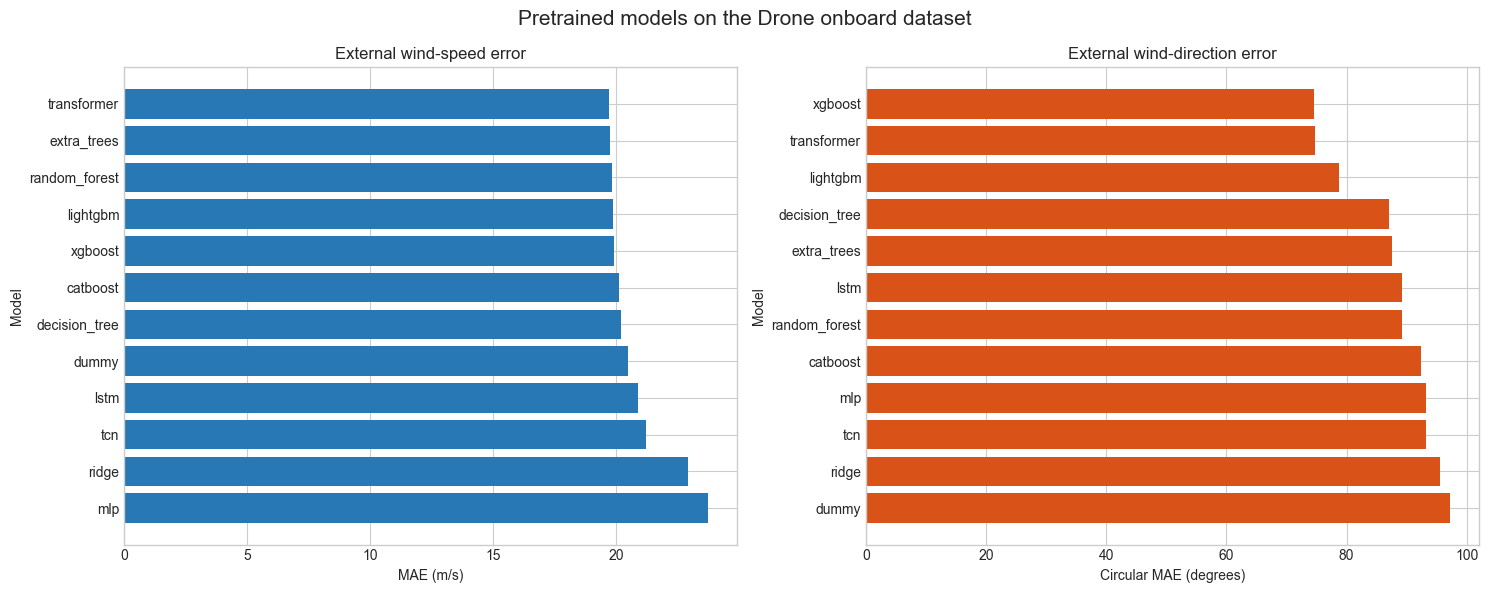

In [6]:
ordered_speed = comparison.sort_values('speed_mae_mps')
ordered_direction = comparison.sort_values('direction_circular_mae_deg')
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
axes[0].barh(ordered_speed['model'], ordered_speed['speed_mae_mps'], color='#2878B5')
axes[0].invert_yaxis()
axes[0].set(title='External wind-speed error', xlabel='MAE (m/s)', ylabel='Model')
axes[1].barh(ordered_direction['model'], ordered_direction['direction_circular_mae_deg'], color='#D95319')
axes[1].invert_yaxis()
axes[1].set(title='External wind-direction error', xlabel='Circular MAE (degrees)', ylabel='Model')
fig.suptitle('Pretrained models on the Drone onboard dataset', fontsize=15)
fig.tight_layout()
fig.savefig(FIGURES_DIR / '01_overall_model_errors.png', dpi=300, bbox_inches='tight')
fig.savefig(FIGURES_DIR / '01_overall_model_errors.pdf', bbox_inches='tight')
plt.show()

In [7]:
# ============================================================
# CREATE PER-FLIGHT MODEL COMPARISON CSV
# Run after Cell 3 has created models and frames.
# ============================================================
'''

from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display


if "models" not in globals() or "frames" not in globals():
    raise RuntimeError(
        "Run Cell 3 first so that models and frames are available."
    )


# Use the output folder for the current external dataset.
OUTPUT_DIR = (
    PROJECT_ROOT
    / "results"
    / "external_drone_onboard"
)

OUTPUT_DIR.mkdir(
    parents=True,
    exist_ok=True,
)

PER_FLIGHT_FILE = (
    OUTPUT_DIR
    / "per_flight_model_comparison.csv"
)


def _split_group_id(group_id: str) -> tuple[str, str]:
    """
    Convert a group such as:
        KIOS_M300::flight_01

    into:
        Source_dataset = KIOS_M300
        Flight_ID = flight_01
    """
    text = str(group_id)

    if "::" in text:
        source_dataset, flight_id = text.split(
            "::",
            maxsplit=1,
        )
    else:
        source_dataset = "unknown"
        flight_id = text

    return source_dataset, flight_id


def _safe_correlation(
    actual: pd.Series,
    predicted: pd.Series,
) -> float:
    valid = (
        actual.notna()
        & predicted.notna()
    )

    actual_valid = actual.loc[valid]
    predicted_valid = predicted.loc[valid]

    if (
        len(actual_valid) < 2
        or actual_valid.nunique() < 2
        or predicted_valid.nunique() < 2
    ):
        return np.nan

    return float(
        actual_valid.corr(predicted_valid)
    )


per_flight_rows = []

for model_name, frame in frames.items():

    data = frame.copy()

    if "group_id" not in data.columns:
        raise KeyError(
            f"{model_name} frame has no group_id column."
        )

    # Support either absolute-error columns or signed-error columns.
    if "abs_speed_error" in data.columns:
        data["_abs_speed_error"] = pd.to_numeric(
            data["abs_speed_error"],
            errors="coerce",
        ).abs()

    elif "speed_error" in data.columns:
        data["_abs_speed_error"] = pd.to_numeric(
            data["speed_error"],
            errors="coerce",
        ).abs()

    else:
        data["_abs_speed_error"] = (
            pd.to_numeric(
                data["pred_speed"],
                errors="coerce",
            )
            - pd.to_numeric(
                data["true_speed"],
                errors="coerce",
            )
        ).abs()

    if "abs_direction_error" in data.columns:
        data["_abs_direction_error"] = pd.to_numeric(
            data["abs_direction_error"],
            errors="coerce",
        ).abs()

    elif "direction_error" in data.columns:
        data["_abs_direction_error"] = pd.to_numeric(
            data["direction_error"],
            errors="coerce",
        ).abs()

    else:
        true_angle = pd.to_numeric(
            data["true_angle"],
            errors="coerce",
        )

        predicted_angle = pd.to_numeric(
            data["pred_angle"],
            errors="coerce",
        )

        data["_abs_direction_error"] = np.abs(
            (
                predicted_angle
                - true_angle
                + 180.0
            )
            % 360.0
            - 180.0
        )

    data["_true_speed"] = pd.to_numeric(
        data["true_speed"],
        errors="coerce",
    )

    data["_pred_speed"] = pd.to_numeric(
        data["pred_speed"],
        errors="coerce",
    )

    for group_id, flight in data.groupby(
        "group_id",
        sort=True,
        observed=True,
    ):

        source_dataset, flight_id = (
            _split_group_id(group_id)
        )

        speed_error = (
            flight["_abs_speed_error"]
            .dropna()
        )

        direction_mask = (
            flight["_true_speed"]
            > DIRECTION_MIN_SPEED
        )

        direction_error = (
            flight.loc[
                direction_mask,
                "_abs_direction_error",
            ]
            .dropna()
        )

        speed_mae = (
            float(speed_error.mean())
            if len(speed_error)
            else np.nan
        )

        speed_rmse = (
            float(
                np.sqrt(
                    np.mean(
                        speed_error.to_numpy() ** 2
                    )
                )
            )
            if len(speed_error)
            else np.nan
        )

        per_flight_rows.append({
            "model": model_name,
            "display_name": (
                models[model_name].display_name
            ),
            "hardware": getattr(
                models[model_name],
                "hardware",
                "unknown",
            ),
            "Source_dataset": source_dataset,
            "Flight_ID": flight_id,
            "group_id": str(group_id),

            "n": int(len(flight)),
            "speed_n": int(len(speed_error)),
            "direction_n": int(
                len(direction_error)
            ),

            "speed_mae_mps": speed_mae,
            "speed_rmse_mps": speed_rmse,
            "speed_r": _safe_correlation(
                flight["_true_speed"],
                flight["_pred_speed"],
            ),

            "direction_mae_deg": (
                float(direction_error.mean())
                if len(direction_error)
                else np.nan
            ),

            "direction_median_deg": (
                float(direction_error.median())
                if len(direction_error)
                else np.nan
            ),

            "direction_p90_deg": (
                float(
                    direction_error.quantile(0.90)
                )
                if len(direction_error)
                else np.nan
            ),

            "direction_min_speed_mps": (
                DIRECTION_MIN_SPEED
            ),
        })


per_flight = (
    pd.DataFrame(per_flight_rows)
    .sort_values(
        [
            "model",
            "speed_mae_mps",
            "Flight_ID",
        ],
        ascending=[
            True,
            True,
            True,
        ],
    )
    .reset_index(drop=True)
)

if per_flight.empty:
    raise RuntimeError(
        "No per-flight metrics were created."
    )

per_flight.to_csv(
    PER_FLIGHT_FILE,
    index=False,
)

print(f"Per-flight rows: {len(per_flight):,}")
print(f"Models:          {per_flight['model'].nunique():,}")
print(f"Flights:         {per_flight['Flight_ID'].nunique():,}")
print(f"Saved file:      {PER_FLIGHT_FILE}")

display(
    per_flight.head(20).style.format({
        "n": "{:,.0f}",
        "speed_n": "{:,.0f}",
        "direction_n": "{:,.0f}",
        "speed_mae_mps": "{:.4f}",
        "speed_rmse_mps": "{:.4f}",
        "speed_r": "{:.4f}",
        "direction_mae_deg": "{:.2f}",
        "direction_median_deg": "{:.2f}",
        "direction_p90_deg": "{:.2f}",
    })
)
'''

# evaluate_all() already creates this table during the evaluation cell.
# Load that canonical output instead of relying on notebook-only variables.
PER_FLIGHT_FILE = OUTPUT_DIR / "per_flight_model_comparison.csv"
if not PER_FLIGHT_FILE.exists():
    raise FileNotFoundError(
        f"Per-flight results were not found at {PER_FLIGHT_FILE}. "
        "Run the saved-model evaluation cell above first."
    )

per_flight = pd.read_csv(PER_FLIGHT_FILE)
per_flight["Flight_ID"] = per_flight["Flight_ID"].astype(str)
print(f"Loaded {len(per_flight):,} per-flight model rows from {PER_FLIGHT_FILE}")
per_flight.head(20)

Loaded 240 per-flight model rows from C:\Users\katel\BU-RISE\Project\3D-Wind_Visualization\wind_ml_pipeline_12_models\results\external_drone_onboard\per_flight_model_comparison.csv


,model,_Group_ID,Flight_ID,rows_evaluated,mean_true_speed_mps,mean_true_direction_deg,speed_bias_mps,speed_mae_mps,speed_rmse_mps,direction_bias_deg,direction_circular_mae_deg,direction_circular_rmse_deg,direction_within_30deg_fraction,direction_speed_ge_1_mps_mae_deg
0,extra_trees,Drone_onboard_multimodal::1,1,15729,20.850804,169.618539,-16.524101,16.808544,25.649482,5.265148,88.560362,100.660734,0.136944,90.137576
1,extra_trees,Drone_onboard_multimodal::10,10,17491,20.851077,230.008347,-15.561082,16.320200,25.862920,-4.748880,86.498245,99.567813,0.136527,89.722533
2,extra_trees,Drone_onboard_multimodal::11,11,15454,24.403104,215.823153,-19.491738,20.125433,30.238416,2.400236,87.069039,100.287100,0.157953,88.703020
3,extra_trees,Drone_onboard_multimodal::12,12,6970,22.326413,227.937016,-17.884769,18.454308,28.439810,-13.859096,87.353057,99.686477,0.147920,89.473917
4,extra_trees,Drone_onboard_multimodal::13,13,5974,21.458070,205.009374,-18.519735,18.869841,31.808101,-13.688382,80.887014,95.639289,0.208570,87.068902
5,extra_trees,Drone_onboard_multimodal::14,14,17051,19.318010,225.639787,-14.460640,15.325605,24.026413,3.089787,87.539766,101.516316,0.174007,87.247162
6,extra_trees,Drone_onboard_multimodal::15,15,16792,19.376639,231.311756,-14.711053,15.210035,23.663492,-9.230622,90.035064,101.634402,0.143878,88.988124
7,extra_trees,Drone_onboard_multimodal::16,16,5230,18.699532,211.526195,-16.282046,16.448036,26.468392,-10.258699,99.065923,109.028523,0.088910,100.455100
8,extra_trees,Drone_onboard_multimodal::17,17,12131,21.971626,204.957217,-17.285101,17.958465,30.060421,1.380655,84.794710,99.660299,0.195038,88.408086
9,extra_trees,Drone_onboard_multimodal::18,18,13645,27.444784,238.490583,-23.055237,23.446167,34.353259,0.790839,87.891753,100.175535,0.138366,88.741569


## 4. Per-flight comparison table

Direction errors are circular: for example, predicting 2° when the true angle is 358° produces a 4° error, not 356°. The `direction_speed_ge_1_mps_mae_deg` column restricts direction scoring to rows where direction is more reliable.

In [8]:
PER_FLIGHT_FILE = OUTPUT_DIR / 'per_flight_model_comparison.csv'
per_flight = pd.read_csv(PER_FLIGHT_FILE)
per_flight['Flight_ID'] = per_flight['Flight_ID'].astype(str)
print(f'Per-flight rows: {len(per_flight):,}')
per_flight.sort_values(['Flight_ID', 'speed_mae_mps']).head(30)

Per-flight rows: 240


,model,_Group_ID,Flight_ID,rows_evaluated,mean_true_speed_mps,mean_true_direction_deg,speed_bias_mps,speed_mae_mps,speed_rmse_mps,direction_bias_deg,direction_circular_mae_deg,direction_circular_rmse_deg,direction_within_30deg_fraction,direction_speed_ge_1_mps_mae_deg
220,transformer,Drone_onboard_multimodal::1,1,15700,20.887154,169.877643,-16.029574,16.660686,25.354940,46.584291,84.772822,100.697603,0.241529,83.644098
0,extra_trees,Drone_onboard_multimodal::1,1,15729,20.850804,169.618539,-16.524101,16.808544,25.649482,5.265148,88.560362,100.660734,0.136944,90.137576
20,random_forest,Drone_onboard_multimodal::1,1,15729,20.850804,169.618539,-16.343916,16.851032,25.627567,21.614827,83.073579,97.980376,0.208278,84.565331
100,xgboost,Drone_onboard_multimodal::1,1,15729,20.850804,169.618539,-16.381071,16.887751,25.671419,3.130752,98.891311,110.070967,0.107318,102.184480
120,lightgbm,Drone_onboard_multimodal::1,1,15729,20.850804,169.618539,-16.574626,16.981483,25.771426,11.208808,90.597015,102.710911,0.137390,93.267466
140,catboost,Drone_onboard_multimodal::1,1,15729,20.850804,169.618539,-16.816729,17.104486,25.905097,5.464924,78.196239,91.813445,0.196071,79.236766
80,dummy,Drone_onboard_multimodal::1,1,15729,20.850804,169.618539,-16.598375,17.496277,25.937910,15.391825,77.149858,87.341710,0.155318,74.317704
40,decision_tree,Drone_onboard_multimodal::1,1,15729,20.850804,169.618539,-16.964202,17.567567,26.152046,4.357477,83.188365,98.621248,0.212728,85.612509
180,lstm,Drone_onboard_multimodal::1,1,15700,20.887154,169.877643,-17.654741,18.011541,26.554004,26.751379,78.483433,89.702268,0.150573,75.801146
200,tcn,Drone_onboard_multimodal::1,1,15700,20.887154,169.877643,-18.537712,18.940729,27.231069,30.756135,82.072515,95.435963,0.172484,79.944801


In [9]:
best_by_flight = (
    per_flight.loc[per_flight.groupby('Flight_ID')['speed_mae_mps'].idxmin(), ['Flight_ID', 'model', 'speed_mae_mps']]
    .rename(columns={'model': 'best_speed_model', 'speed_mae_mps': 'best_speed_mae_mps'})
    .merge(
        per_flight.loc[per_flight.groupby('Flight_ID')['direction_circular_mae_deg'].idxmin(), ['Flight_ID', 'model', 'direction_circular_mae_deg']]
        .rename(columns={'model': 'best_direction_model', 'direction_circular_mae_deg': 'best_direction_mae_deg'}),
        on='Flight_ID', how='outer'
    )
    .sort_values('Flight_ID', key=lambda s: pd.to_numeric(s, errors='coerce'))
)
best_by_flight.to_csv(OUTPUT_DIR / 'best_model_by_flight.csv', index=False)
best_by_flight

,Flight_ID,best_speed_model,best_speed_mae_mps,best_direction_model,best_direction_mae_deg
0,1,transformer,16.660686,ridge,73.905203
11,2,transformer,17.099836,xgboost,71.840682
13,3,lightgbm,20.624613,transformer,71.534171
14,4,transformer,25.327362,xgboost,71.534864
15,5,transformer,21.753883,xgboost,69.125572
16,6,extra_trees,25.885809,xgboost,69.851743
17,7,lightgbm,22.000831,xgboost,66.510566
18,8,transformer,19.598250,transformer,74.482810
19,9,extra_trees,22.581073,transformer,70.613560
1,10,transformer,16.303558,transformer,68.579137


## 5. Model-by-flight error heatmaps

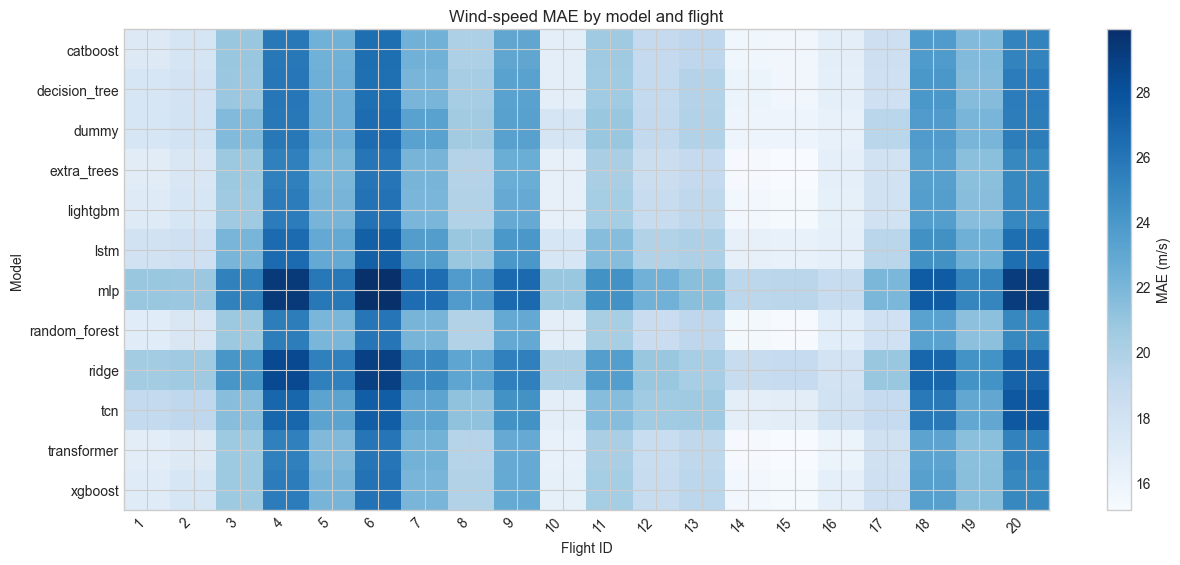

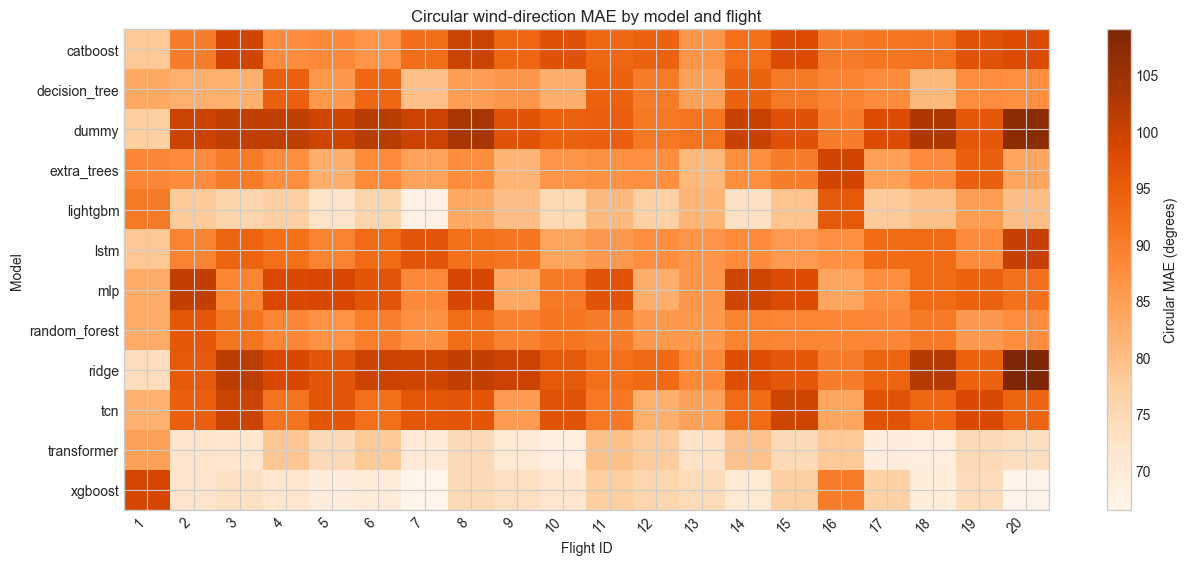

In [10]:
def plot_error_heatmap(metric, title, colorbar_label, filename, cmap='viridis'):
    matrix = per_flight.pivot(index='model', columns='Flight_ID', values=metric)
    numeric_order = sorted(matrix.columns, key=lambda x: float(x) if str(x).replace('.', '', 1).isdigit() else str(x))
    matrix = matrix.reindex(columns=numeric_order)
    fig, ax = plt.subplots(figsize=(max(12, 0.65 * len(matrix.columns)), max(5, 0.48 * len(matrix.index))))
    image = ax.imshow(matrix.to_numpy(), aspect='auto', cmap=cmap)
    ax.set_xticks(range(len(matrix.columns)), matrix.columns, rotation=45, ha='right')
    ax.set_yticks(range(len(matrix.index)), matrix.index)
    ax.set(xlabel='Flight ID', ylabel='Model', title=title)
    colorbar = fig.colorbar(image, ax=ax)
    colorbar.set_label(colorbar_label)
    fig.tight_layout()
    fig.savefig(FIGURES_DIR / f'{filename}.png', dpi=300, bbox_inches='tight')
    fig.savefig(FIGURES_DIR / f'{filename}.pdf', bbox_inches='tight')
    plt.show()
    return matrix

speed_heatmap = plot_error_heatmap(
    'speed_mae_mps', 'Wind-speed MAE by model and flight', 'MAE (m/s)', '02_speed_mae_by_flight', 'Blues'
)
direction_heatmap = plot_error_heatmap(
    'direction_circular_mae_deg', 'Circular wind-direction MAE by model and flight', 'Circular MAE (degrees)', '03_direction_mae_by_flight', 'Oranges'
)

## 6. Error for every flight

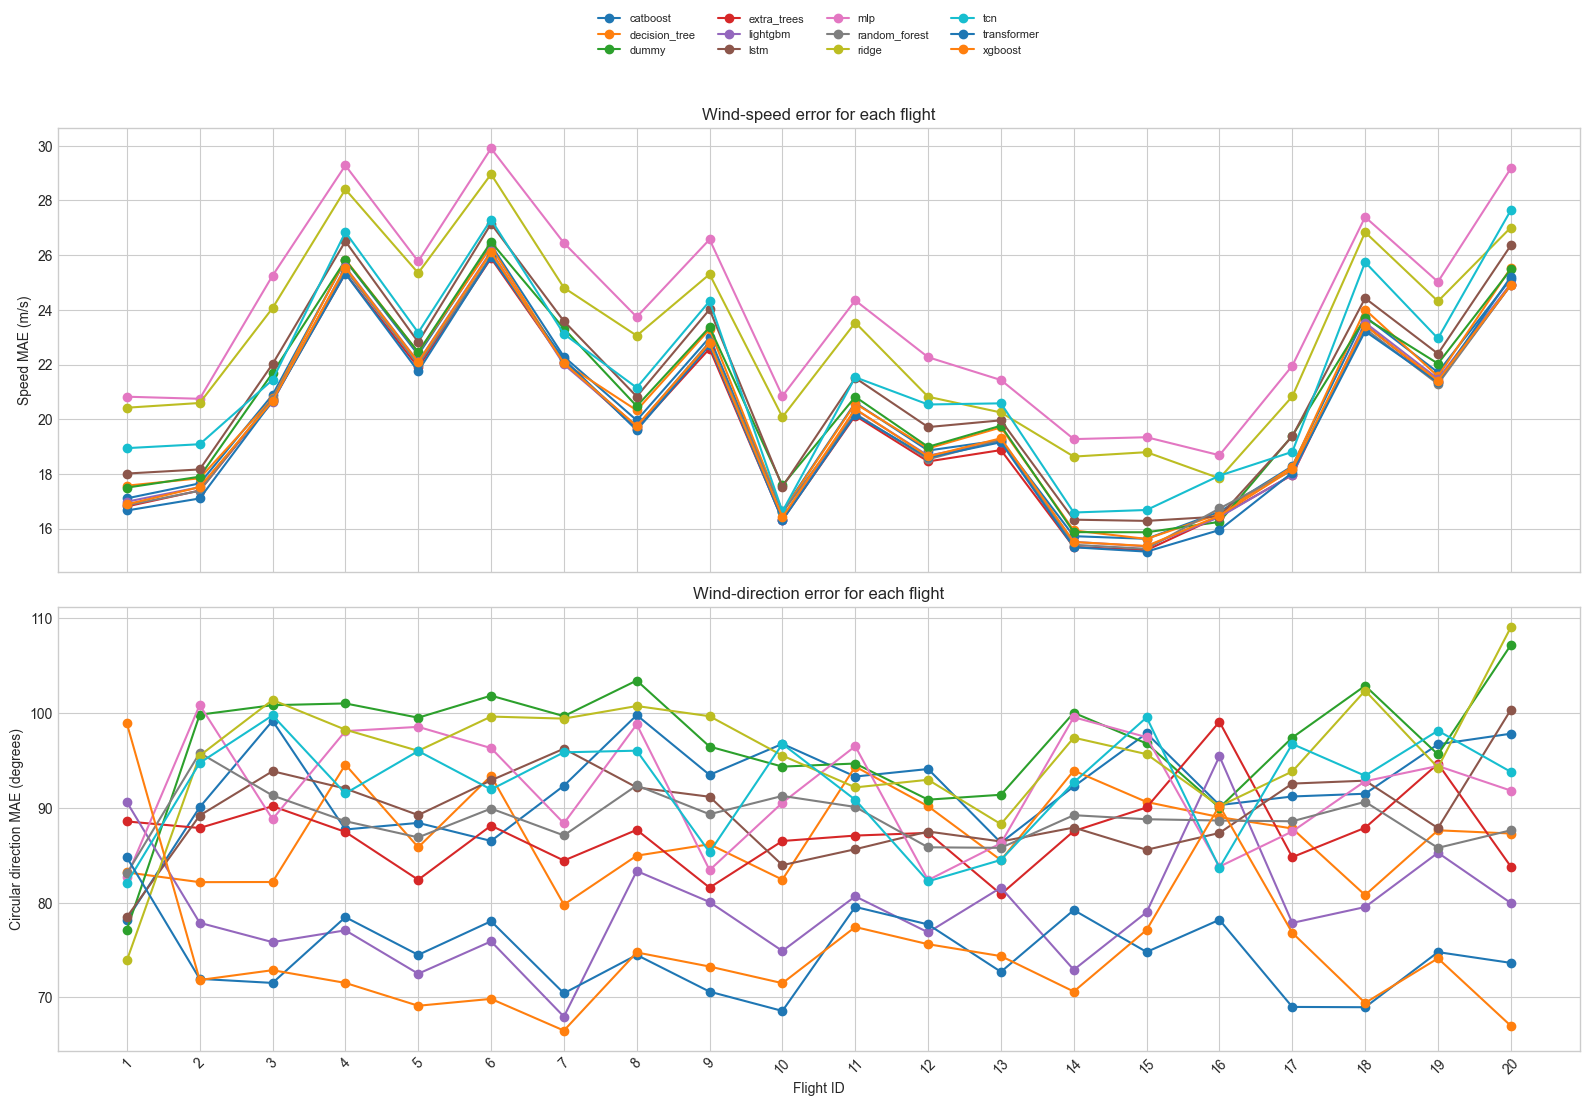

In [11]:
flight_order = sorted(per_flight['Flight_ID'].unique(), key=lambda x: float(x) if str(x).replace('.', '', 1).isdigit() else str(x))
fig, axes = plt.subplots(2, 1, figsize=(16, 11), sharex=True)
for model, part in per_flight.groupby('model', sort=True):
    indexed = part.set_index('Flight_ID').reindex(flight_order)
    axes[0].plot(flight_order, indexed['speed_mae_mps'], marker='o', linewidth=1.5, label=model)
    axes[1].plot(flight_order, indexed['direction_circular_mae_deg'], marker='o', linewidth=1.5, label=model)
axes[0].set(ylabel='Speed MAE (m/s)', title='Wind-speed error for each flight')
axes[1].set(xlabel='Flight ID', ylabel='Circular direction MAE (degrees)', title='Wind-direction error for each flight')
axes[1].tick_params(axis='x', rotation=45)
axes[0].legend(ncol=4, fontsize=8, loc='upper center', bbox_to_anchor=(0.5, 1.28))
fig.tight_layout()
fig.savefig(FIGURES_DIR / '04_all_models_each_flight.png', dpi=300, bbox_inches='tight')
fig.savefig(FIGURES_DIR / '04_all_models_each_flight.pdf', bbox_inches='tight')
plt.show()

## 7. Distribution of flight-level errors

C:\Users\katel\AppData\Local\Temp\ipykernel_24436\161148393.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(speed_groups, labels=models, showmeans=True)
C:\Users\katel\AppData\Local\Temp\ipykernel_24436\161148393.py:7: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(direction_groups, labels=models, showmeans=True)


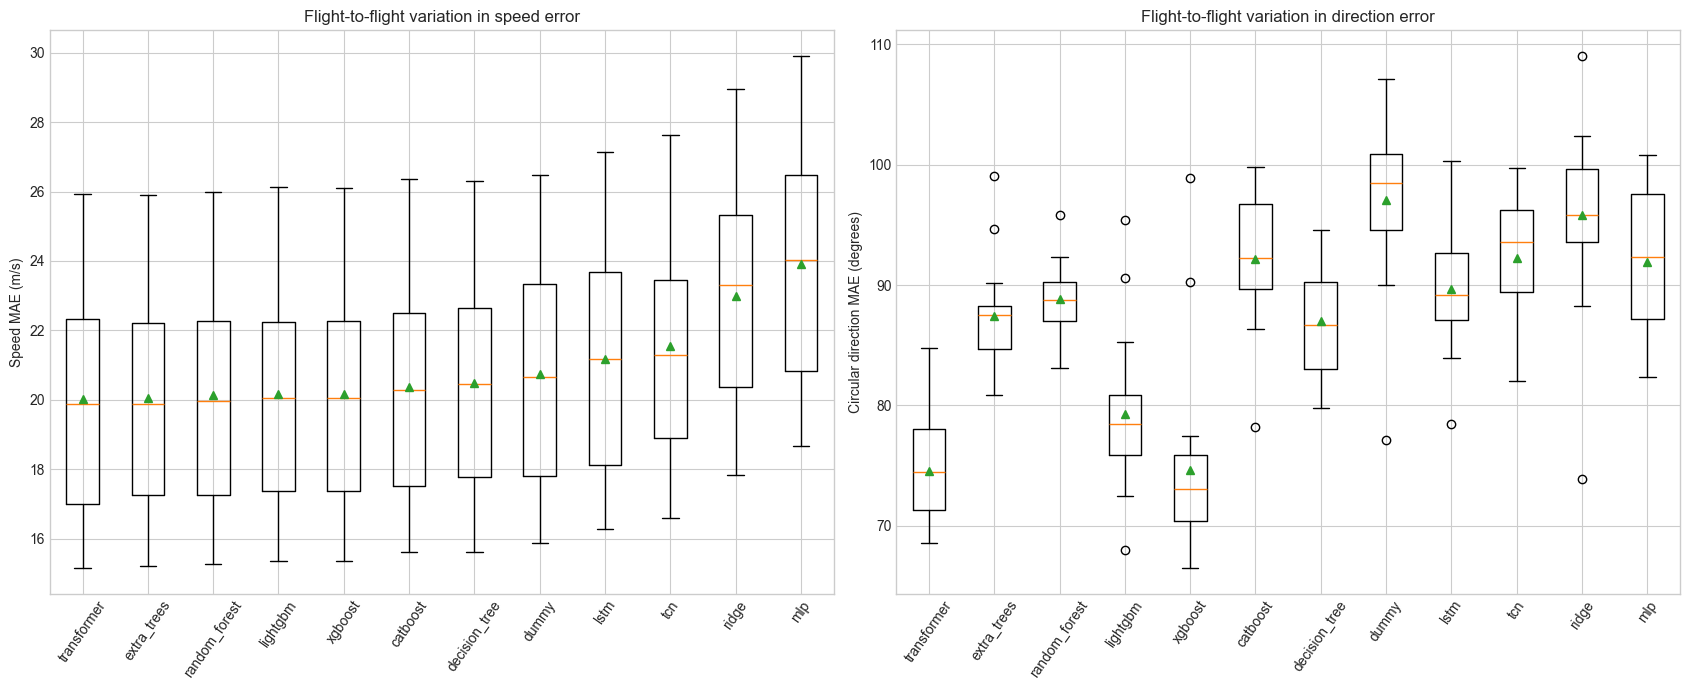

In [12]:
models = comparison.sort_values('speed_mae_mps')['model'].tolist()
speed_groups = [per_flight.loc[per_flight.model == model, 'speed_mae_mps'].dropna() for model in models]
direction_groups = [per_flight.loc[per_flight.model == model, 'direction_circular_mae_deg'].dropna() for model in models]
fig, axes = plt.subplots(1, 2, figsize=(17, 7))
axes[0].boxplot(speed_groups, labels=models, showmeans=True)
axes[0].set(title='Flight-to-flight variation in speed error', ylabel='Speed MAE (m/s)')
axes[1].boxplot(direction_groups, labels=models, showmeans=True)
axes[1].set(title='Flight-to-flight variation in direction error', ylabel='Circular direction MAE (degrees)')
for ax in axes:
    ax.tick_params(axis='x', rotation=55)
fig.tight_layout()
fig.savefig(FIGURES_DIR / '05_per_flight_error_distributions.png', dpi=300, bbox_inches='tight')
fig.savefig(FIGURES_DIR / '05_per_flight_error_distributions.pdf', bbox_inches='tight')
plt.show()

## 8. Bias diagnostics

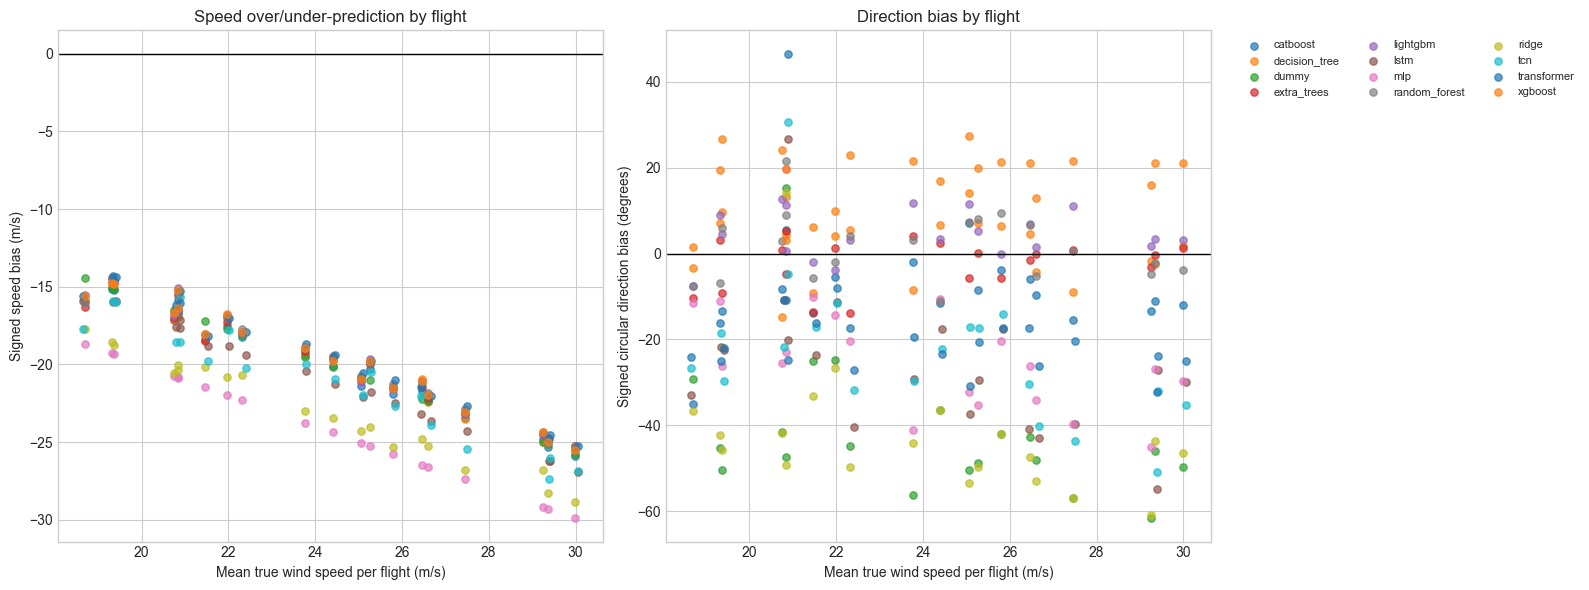

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
for model, part in per_flight.groupby('model', sort=True):
    axes[0].scatter(part['mean_true_speed_mps'], part['speed_bias_mps'], s=28, alpha=0.7, label=model)
    axes[1].scatter(part['mean_true_speed_mps'], part['direction_bias_deg'], s=28, alpha=0.7, label=model)
axes[0].axhline(0, color='black', linewidth=1)
axes[1].axhline(0, color='black', linewidth=1)
axes[0].set(xlabel='Mean true wind speed per flight (m/s)', ylabel='Signed speed bias (m/s)', title='Speed over/under-prediction by flight')
axes[1].set(xlabel='Mean true wind speed per flight (m/s)', ylabel='Signed circular direction bias (degrees)', title='Direction bias by flight')
axes[1].legend(ncol=3, fontsize=8, bbox_to_anchor=(1.04, 1), loc='upper left')
fig.tight_layout()
fig.savefig(FIGURES_DIR / '06_per_flight_bias_diagnostics.png', dpi=300, bbox_inches='tight')
fig.savefig(FIGURES_DIR / '06_per_flight_bias_diagnostics.pdf', bbox_inches='tight')
plt.show()

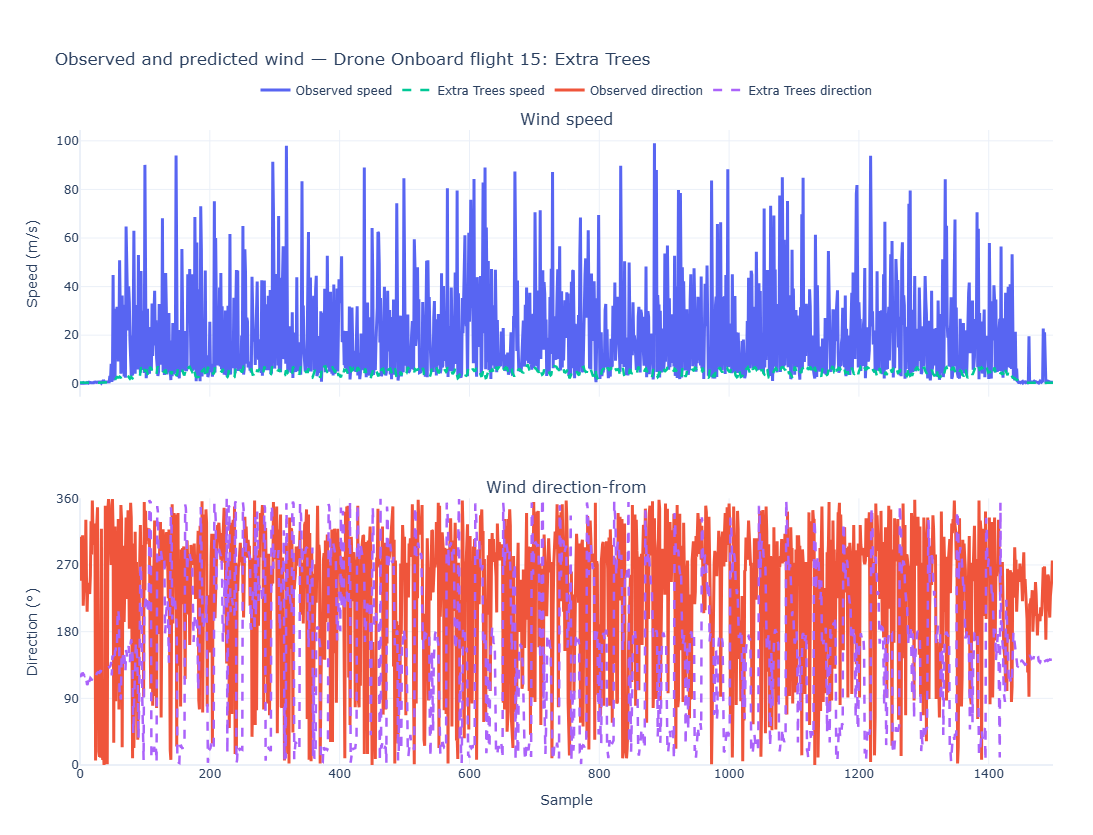

Interactive figure saved to:
C:\Users\katel\BU-RISE\Project\3D-Wind_Visualization\wind_ml_pipeline_12_models\results\external_drone_onboard\figures\observed_vs_predicted_extra_trees_flight_15.html


C:\Users\katel\BU-RISE\Project\3D-Wind_Visualization\wind_ml_pipeline_12_models\results\external_drone_onboard\figures\observed_vs_predicted_extra_trees_flight_15.html


The interactive HTML was saved successfully, but PNG export requires the Kaleido package.
Install it with: pip install kaleido
PNG export message: 
Image export using the "kaleido" engine requires the Kaleido package,
which can be installed using pip:

    $ pip install --upgrade kaleido



In [18]:
# ----------------------------
# Display and save figure
# ----------------------------
from IPython.display import FileLink, display

FIGURE_OUTPUT_DIR = OUTPUT_DIR / "figures"
FIGURE_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

safe_model_name = MODEL_NAME.replace(" ", "_").lower()
safe_flight_id = str(selected_flight).replace(" ", "_")

figure_stem = (
    f"observed_vs_predicted_"
    f"{safe_model_name}_flight_{safe_flight_id}"
)

HTML_FILE = FIGURE_OUTPUT_DIR / f"{figure_stem}.html"
PNG_FILE = FIGURE_OUTPUT_DIR / f"{figure_stem}.png"

# Show the interactive graph in the notebook.
fig.show()

# Save an interactive version. This does not require Kaleido.
fig.write_html(
    HTML_FILE,
    include_plotlyjs=True,
    full_html=True,
)

print(f"Interactive figure saved to:\n{HTML_FILE}")
display(FileLink(str(HTML_FILE), result_html_prefix="Download interactive HTML: "))

# Save a high-resolution static image.
try:
    fig.write_image(
        PNG_FILE,
        width=1800,
        height=1000,
        scale=2,
    )

    print(f"PNG figure saved to:\n{PNG_FILE}")
    display(FileLink(str(PNG_FILE), result_html_prefix="Download PNG: "))

except Exception as exc:
    print(
        "\nThe interactive HTML was saved successfully, "
        "but PNG export requires the Kaleido package."
    )
    print("Install it with: pip install kaleido")
    print(f"PNG export message: {exc}")

## 9. Export summary

In [14]:
print('Saved tables:')
for path in sorted(OUTPUT_DIR.glob('*.csv')):
    print('  ', path.name)
print('\nSaved figures:')
for path in sorted(FIGURES_DIR.glob('*')):
    print('  ', path.name)

display(comparison.sort_values('flight_balanced_speed_mae_mps'))

Saved tables:
   best_model_by_flight.csv
   model_comparison.csv
   model_failures.csv
   per_flight_model_comparison.csv

Saved figures:
   01_overall_model_errors.pdf
   01_overall_model_errors.png
   02_speed_mae_by_flight.pdf
   02_speed_mae_by_flight.png
   03_direction_mae_by_flight.pdf
   03_direction_mae_by_flight.png
   04_all_models_each_flight.pdf
   04_all_models_each_flight.png
   05_per_flight_error_distributions.pdf
   05_per_flight_error_distributions.png
   06_per_flight_bias_diagnostics.pdf
   06_per_flight_bias_diagnostics.png


,model,rows_evaluated,flights_evaluated,speed_mae_mps,speed_rmse_mps,speed_r2,direction_circular_mae_deg,direction_within_30deg_fraction,direction_speed_ge_1_mps_mae_deg,flight_balanced_speed_mae_mps,flight_balanced_direction_mae_deg,artifact
0,transformer,256390,20,19.735971,30.464978,-0.594994,74.665977,0.218589,74.293928,20.019643,74.596973,C:\Users\katel\BU-RISE\Project\3D-Wind_Visuali...
1,extra_trees,256970,20,19.772866,30.574574,-0.607157,87.481525,0.157143,88.776086,20.036972,87.391969,C:\Users\katel\BU-RISE\Project\3D-Wind_Visuali...
2,random_forest,256970,20,19.855493,30.570218,-0.606699,89.179027,0.166292,90.592507,20.133014,88.825944,C:\Users\katel\BU-RISE\Project\3D-Wind_Visuali...
3,lightgbm,256970,20,19.894142,30.629423,-0.612928,78.796279,0.195980,79.238136,20.156764,79.256475,C:\Users\katel\BU-RISE\Project\3D-Wind_Visuali...
4,xgboost,256970,20,19.901644,30.640382,-0.614083,74.563374,0.205966,74.614457,20.168239,74.644795,C:\Users\katel\BU-RISE\Project\3D-Wind_Visuali...
5,catboost,256970,20,20.122905,30.905786,-0.642166,92.316565,0.143822,94.064638,20.378361,92.180123,C:\Users\katel\BU-RISE\Project\3D-Wind_Visuali...
6,decision_tree,256970,20,20.221244,30.783502,-0.629197,87.004539,0.175242,86.855158,20.483904,87.032239,C:\Users\katel\BU-RISE\Project\3D-Wind_Visuali...
7,dummy,256970,20,20.494760,31.026644,-0.655034,97.197668,0.102670,98.454815,20.735277,97.035621,C:\Users\katel\BU-RISE\Project\3D-Wind_Visuali...
8,lstm,256390,20,20.913199,31.597943,-0.715833,89.152011,0.122087,89.830170,21.169552,89.658306,C:\Users\katel\BU-RISE\Project\3D-Wind_Visuali...
9,tcn,256390,20,21.211487,31.647550,-0.721225,93.261120,0.112785,94.068132,21.548676,92.268344,C:\Users\katel\BU-RISE\Project\3D-Wind_Visuali...
